# Cross-Condition Network Analysis: CWL vs. BWL

**Purpose:** This notebook implements a correlation-based network analysis
comparing two experimental conditions (CWL and BWL) on 8 psychological
construct nodes across 4 subsystems. Between-condition differences in
global network metrics, node strength, and edge weights are tested using
sign-flip permutation inference (10,000 permutations) with FDR correction.

**Pipeline Overview:**
1. Load paired repeated-measures data
2. Construct weighted networks via thresholded Spearman correlations
3. Compute global and node-level network metrics for each condition
4. Run sign-flip permutation tests for all between-condition differences
5. Visualize networks, dissociation patterns, and rank changes
6. Export all statistical tables

**Requirements:** See `requirements.txt`. Core dependencies are
`numpy`, `pandas`, `networkx`, `scipy`, `statsmodels`, `matplotlib`,
`joblib`, and `tqdm`.

**How to Run:** Place your data file in `./data/CAN.xlsx`, then run
all cells sequentially from top to bottom.

In [1]:
# ============================================================
#  Cell 1 — CONFIGURATION
#  All adjustable parameters are centralised here.
#  Modify this cell only; downstream cells reference these values.
# ============================================================

from pathlib import Path

# ── File Paths ──────────────────────────────────────────────
# Relative paths so the notebook is portable.
# Place your data file at ./data/CAN.xlsx before running.
DATA_FILE  = Path("CAN.xlsx")
SHEET_NAME = "Sheet1"

EXPORT_DIR = Path("./output")
FIG_DIR    = EXPORT_DIR / "figures"
TAB_DIR    = EXPORT_DIR / "tables"

# ── Study Design ────────────────────────────────────────────
CONDITION_COL = "order"
COND1, COND2  = "1", "2"           # 1 = CWL, 2 = BWL
COND1_LABEL   = "CWL"
COND2_LABEL   = "BWL"

NODE_COLS = [
    "A2", "A5", "A12",
    "B1", "B3", "B4",
    "C3",
    "D5",
]

SUBSYSTEM_COLORS = {
    "A": "#C1565E",
    "B": "#A8CBDF",
    "C": "#73A5A2",
    "D": "#8074C8",
}

# ── Statistical Parameters ──────────────────────────────────
CORR_METHOD = "spearman"            # "spearman" or "pearson"
EDGE_ALPHA  = 0.05                  # p-value threshold for retaining edges
ALPHA       = 0.05                  # significance level for reporting
N_PERM      = 10_000                # number of sign-flip permutations
RANDOM_SEED = 20260327
N_JOBS      = -1                    # parallel cores (-1 = all)

# ── Univariate p-values (from paired comparisons in main text) ──
# ★ VERIFY these values match your manuscript before final upload.
UNIVARIATE_P = {
    "A2":  0.046,
    "A5":  0.588,
    "A12": 0.263,
    "B1":  0.035,
    "B3":  0.570,       # ← confirm this value
    "B4":  0.024,       # ← confirm this value
    "C3":  0.004,
    "D5":  0.0001,
}

# ── Figure Aesthetics ───────────────────────────────────────
FIG_DPI          = 600              # 300 for drafts, 600 for submission
FIG_FORMAT       = "png"
FONT_FAMILY      = ["Arial", "Helvetica", "DejaVu Sans"]
NODE_SIZE_RANGE  = (700, 2600)      # (min, max) for network plots
EDGE_WIDTH_RANGE = (0.8, 5.0)      # (min, scale_factor)
EDGE_COLOR       = "#3C5488"
EDGE_HALO_COLOR  = "#D0D7E5"
SIG_HIGHLIGHT    = "#ffcccc"        # background colour for p < α

# ── Small-world (descriptive) ──────────────────────────────
SW_N_RAND = 100
SW_SEED   = 42

print("✅ Configuration loaded.")

✅ Configuration loaded.


## Data Loading & Validation

In [2]:
# ============================================================
#  Cell 2 — IMPORTS & DATA LOADING
# ============================================================

import os
import warnings
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, spearmanr, ConstantInputWarning, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from joblib import Parallel, delayed
from tqdm.auto import tqdm

# Create output directories
for d in [FIG_DIR, TAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Global matplotlib settings
plt.rcParams.update({
    "pdf.fonttype":    42,
    "ps.fonttype":     42,
    "font.family":     "sans-serif",
    "font.sans-serif": FONT_FAMILY,
})

# ── Load data ───────────────────────────────────────────────
df_raw = pd.read_excel(DATA_FILE, sheet_name=SHEET_NAME)
df_raw[CONDITION_COL] = df_raw[CONDITION_COL].astype(str).str.strip().str.lower()

if "name" in df_raw.columns:
    df_raw["subject_id"] = df_raw["name"]
else:
    df_raw["subject_id"] = df_raw.groupby(CONDITION_COL).cumcount() + 1
    print("⚠ No 'name' column found; subjects paired by row position.")

# ── Validate ────────────────────────────────────────────────
found_conds = set(df_raw[CONDITION_COL].unique())
assert {COND1, COND2} <= found_conds, \
    f"Data must contain conditions {COND1} and {COND2}, found {found_conds}"

df = df_raw.loc[df_raw[CONDITION_COL].isin({COND1, COND2})].copy()

n_c1 = df.loc[df[CONDITION_COL] == COND1, "subject_id"].nunique()
n_c2 = df.loc[df[CONDITION_COL] == COND2, "subject_id"].nunique()
assert n_c1 == n_c2, f"Group size mismatch: {COND1}={n_c1}, {COND2}={n_c2}"

missing = [c for c in NODE_COLS if c not in df.columns]
assert not missing, f"Missing node columns in data: {missing}"

print(f"✅ Data loaded: {n_c1} subjects × 2 conditions × {len(NODE_COLS)} nodes")
print(f"   Correlation: {CORR_METHOD}  |  Edge threshold: p < {EDGE_ALPHA}  |  Permutations: {N_PERM:,}")

✅ Data loaded: 24 subjects × 2 conditions × 8 nodes
   Correlation: spearman  |  Edge threshold: p < 0.05  |  Permutations: 10,000


## Core Functions: Network Construction, Metrics & Permutation Engine

In [3]:
# ============================================================
#  Cell 3 — FUNCTION DEFINITIONS
# ============================================================

# ── 3.1  Prepare paired data ───────────────────────────────

def prepare_paired(df, node_cols):
    """Align paired subjects across two conditions."""
    d1 = (df.loc[df[CONDITION_COL] == COND1, ["subject_id"] + node_cols]
            .sort_values("subject_id").reset_index(drop=True))
    d2 = (df.loc[df[CONDITION_COL] == COND2, ["subject_id"] + node_cols]
            .sort_values("subject_id").reset_index(drop=True))
    assert len(d1) == len(d2), "Group sizes differ after filtering"
    assert d1["subject_id"].equals(d2["subject_id"]), \
        "Subject IDs do not align between conditions"
    return d1[node_cols].copy(), d2[node_cols].copy()


# ── 3.2  Adjacency matrix from correlations ────────────────

def compute_adjacency(df_num, method=CORR_METHOD, alpha=EDGE_ALPHA):
    """
    Compute pairwise correlations; retain edges with p < alpha.
    Returns absolute-value and signed adjacency matrices.
    """
    cols = list(df_num.columns)
    n = len(cols)
    adj_abs    = pd.DataFrame(0.0, index=cols, columns=cols)
    adj_signed = pd.DataFrame(0.0, index=cols, columns=cols)

    for i in range(n):
        for j in range(i + 1, n):
            sub = df_num.iloc[:, [i, j]].dropna()
            if (len(sub) < 3
                    or sub.iloc[:, 0].nunique() < 2
                    or sub.iloc[:, 1].nunique() < 2):
                r, p = 0.0, 1.0
            else:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", ConstantInputWarning)
                    if method == "pearson":
                        r, p = pearsonr(sub.iloc[:, 0], sub.iloc[:, 1])
                    else:
                        r, p = spearmanr(sub.iloc[:, 0], sub.iloc[:, 1])
            if not np.isfinite(r):
                r, p = 0.0, 1.0
            if p < alpha:
                adj_abs.iat[i, j]    = adj_abs.iat[j, i]    = abs(r)
                adj_signed.iat[i, j] = adj_signed.iat[j, i] = r

    return adj_abs, adj_signed


# ── 3.3  Build NetworkX graph ──────────────────────────────

def adj_to_graph(adj_abs, adj_signed=None):
    """Convert adjacency matrix to a weighted undirected graph."""
    G = nx.Graph()
    cols = list(adj_abs.columns)
    G.add_nodes_from(cols)
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            w = float(adj_abs.iat[i, j])
            if w > 0:
                sw = float(adj_signed.iat[i, j]) if adj_signed is not None else w
                G.add_edge(cols[i], cols[j],
                           weight=w, signed_weight=sw, distance=1.0 / w)
    return G


# ── 3.4  Global network metrics ───────────────────────────

GLOBAL_NAMES = [
    "n_edges", "density", "avg_abs_weight",
    "global_efficiency", "avg_path_length",
    "avg_clustering", "modularity",
]


def weighted_global_efficiency(G):
    """Inverse-distance global efficiency for weighted graphs."""
    n = G.number_of_nodes()
    if n < 2 or G.number_of_edges() == 0:
        return 0.0
    sp = dict(nx.all_pairs_dijkstra_path_length(G, weight="distance"))
    total = sum(
        1.0 / d
        for u in G.nodes()
        for v, d in sp.get(u, {}).items()
        if v != u and np.isfinite(d) and d > 0
    )
    return total / (n * (n - 1))


def compute_global(G):
    """Compute all global network metrics."""
    weights = [d["weight"] for _, _, d in G.edges(data=True)]

    # Subsystem-based modularity
    communities = []
    for prefix in sorted(SUBSYSTEM_COLORS.keys()):
        comm = {n for n in G.nodes() if n.startswith(prefix)}
        if comm:
            communities.append(comm)
    try:
        mod = nx.community.modularity(G, communities, weight="weight")
    except Exception:
        mod = np.nan

    if nx.is_connected(G) and G.number_of_edges() > 0:
        avg_pl = nx.average_shortest_path_length(G, weight="distance")
    else:
        avg_pl = np.nan

    return pd.Series({
        "n_edges":           float(G.number_of_edges()),
        "density":           nx.density(G),
        "avg_abs_weight":    float(np.mean(weights)) if weights else 0.0,
        "global_efficiency": weighted_global_efficiency(G),
        "avg_path_length":   avg_pl,
        "avg_clustering":    (nx.average_clustering(G, weight="weight")
                              if G.number_of_edges() > 0 else 0.0),
        "modularity":        mod,
    })


# ── 3.5  Node metrics (strength) ──────────────────────────

NODE_METRIC_NAMES = ["strength"]


def compute_node_metrics(G, node_cols):
    """Compute node-level metrics; currently strength only."""
    strength = pd.Series(0.0, index=node_cols)
    for nd, val in G.degree(weight="weight"):
        if nd in strength.index:
            strength[nd] = float(val)
    return {"strength": strength}


# ── 3.6  Edge weight extraction ────────────────────────────

def edge_weight_matrix(G, node_cols, attr="signed_weight"):
    """Extract a node × node weight matrix from graph."""
    n = len(node_cols)
    W = np.zeros((n, n))
    idx = {nd: i for i, nd in enumerate(node_cols)}
    for u, v, d in G.edges(data=True):
        i, j = idx[u], idx[v]
        W[i, j] = W[j, i] = d.get(attr, d["weight"])
    return W


# ── 3.7  Analyse one condition ─────────────────────────────

def analyze_one(df_num, node_cols, method=CORR_METHOD, alpha=EDGE_ALPHA):
    """Full single-condition pipeline: adjacency → graph → metrics."""
    adj_abs, adj_signed = compute_adjacency(df_num[node_cols], method=method, alpha=alpha)
    G  = adj_to_graph(adj_abs, adj_signed)
    nm = compute_node_metrics(G, node_cols)
    return {
        "adj": adj_abs, "adj_signed": adj_signed,
        "graph": G, "global": compute_global(G),
        "node_metrics": nm, "strength": nm["strength"],
    }


# ── 3.8  Small-world (descriptive) ────────────────────────

def compute_small_world(G, n_rand=SW_N_RAND, seed=SW_SEED):
    """
    Descriptive small-world indices (sigma, gamma, lambda)
    via weight-shuffled random graphs.
    """
    if not nx.is_connected(G) or G.number_of_edges() < 3:
        return {"sigma": np.nan, "gamma": np.nan, "lambda": np.nan}

    C_obs = nx.average_clustering(G, weight="weight")
    L_obs = nx.average_shortest_path_length(G, weight="distance")

    rng = np.random.default_rng(seed)
    rand_C, rand_L = [], []
    for _ in range(n_rand):
        Gr = G.copy()
        edges = list(Gr.edges(data=True))
        ws = [d["weight"] for _, _, d in edges]
        rng.shuffle(ws)
        for (u, v, d), w in zip(edges, ws):
            Gr[u][v]["weight"]   = w
            Gr[u][v]["distance"] = 1.0 / (w + 1e-10)
        if nx.is_connected(Gr):
            rand_C.append(nx.average_clustering(Gr, weight="weight"))
            rand_L.append(nx.average_shortest_path_length(Gr, weight="distance"))
    if not rand_C:
        return {"sigma": np.nan, "gamma": np.nan, "lambda": np.nan}

    gamma = C_obs / np.mean(rand_C)
    lam   = L_obs / np.mean(rand_L)
    sigma = gamma / lam if lam > 0 else np.nan
    return {"sigma": sigma, "gamma": gamma, "lambda": lam}


# ── 3.9  Single permutation iteration ─────────────────────

def _one_perm(flip, v1, v2, node_cols, method, alpha):
    """Worker function for one sign-flip permutation."""
    p1, p2 = v1.copy(), v2.copy()
    if flip.any():
        p1[flip] = v2[flip]
        p2[flip] = v1[flip]
    d1 = pd.DataFrame(p1, columns=node_cols)
    d2 = pd.DataFrame(p2, columns=node_cols)
    r1 = analyze_one(d1, node_cols, method, alpha)
    r2 = analyze_one(d2, node_cols, method, alpha)

    g_diff = (r2["global"] - r1["global"]).values
    nm_diffs = {}
    for mn in NODE_METRIC_NAMES:
        nm_diffs[mn] = (r2["node_metrics"][mn].reindex(node_cols).values -
                        r1["node_metrics"][mn].reindex(node_cols).values)
    W1 = edge_weight_matrix(r1["graph"], node_cols)
    W2 = edge_weight_matrix(r2["graph"], node_cols)
    e_diff = W2 - W1
    return g_diff, nm_diffs, e_diff


# ── 3.10  FDR helper ──────────────────────────────────────

def _add_fdr(df_in, p_col="p_perm", q_col="q_FDR"):
    """Append Benjamini–Hochberg FDR-corrected q-values."""
    df_out = df_in.copy()
    pvals = df_out[p_col].values.copy()
    mask  = np.isfinite(pvals)
    qvals = np.full_like(pvals, np.nan)
    if mask.sum() > 0:
        _, q, _, _ = multipletests(pvals[mask], method="fdr_bh")
        qvals[mask] = q
    df_out[q_col] = qvals
    return df_out


# ── 3.11  Main analysis pipeline ──────────────────────────

def run_analysis(df, node_cols, method=CORR_METHOD,
                 n_perm=N_PERM, seed=RANDOM_SEED,
                 edge_alpha=EDGE_ALPHA):
    """
    Complete cross-condition network comparison with
    sign-flip permutation inference.
    """
    v1_df, v2_df = prepare_paired(df, node_cols)

    # Observed
    obs1 = analyze_one(v1_df, node_cols, method, edge_alpha)
    obs2 = analyze_one(v2_df, node_cols, method, edge_alpha)

    obs_g = obs2["global"] - obs1["global"]
    obs_nm = {mn: (obs2["node_metrics"][mn].reindex(node_cols) -
                   obs1["node_metrics"][mn].reindex(node_cols))
              for mn in NODE_METRIC_NAMES}

    obs_W1 = edge_weight_matrix(obs1["graph"], node_cols)
    obs_W2 = edge_weight_matrix(obs2["graph"], node_cols)
    obs_edge_diff = obs_W2 - obs_W1

    # Permutations
    rng   = np.random.default_rng(seed)
    flips = rng.random((n_perm, len(v1_df))) < 0.5
    v1, v2 = v1_df.values, v2_df.values

    t0 = time.time()
    print(f"  Running {n_perm:,} sign-flip permutations "
          f"({method}, {len(node_cols)} nodes, edge p < {edge_alpha}) …")

    results_raw = Parallel(n_jobs=N_JOBS)(
        delayed(_one_perm)(flips[b], v1, v2, node_cols, method, edge_alpha)
        for b in range(n_perm)
    )
    elapsed = time.time() - t0
    print(f"  ✓ Completed in {elapsed:.1f} s")

    # Unpack permutation results
    perm_g    = np.array([r[0] for r in results_raw])
    perm_nm   = {mn: np.array([r[1][mn] for r in results_raw])
                 for mn in NODE_METRIC_NAMES}
    perm_edge = np.array([r[2] for r in results_raw])
    n_nd = len(node_cols)

    # p-values: global
    obs_g_arr = obs_g.values
    p_g = np.full(len(GLOBAL_NAMES), np.nan)
    for k in range(len(GLOBAL_NAMES)):
        if np.isfinite(obs_g_arr[k]):
            cnt = np.nansum(np.abs(perm_g[:, k]) >= abs(obs_g_arr[k]))
            p_g[k] = (1 + cnt) / (n_perm + 1)

    # p-values: node metrics
    p_nm = {}
    for mn in NODE_METRIC_NAMES:
        p_nm[mn] = (1 + (np.abs(perm_nm[mn]) >=
                         np.abs(obs_nm[mn].values)).sum(axis=0)) / (n_perm + 1)

    # p-values: edges
    p_edge = np.ones((n_nd, n_nd))
    for i in range(n_nd):
        for j in range(i + 1, n_nd):
            obs_val = abs(obs_edge_diff[i, j])
            perm_vals = np.abs(perm_edge[:, i, j])
            p_edge[i, j] = p_edge[j, i] = \
                (1 + (perm_vals >= obs_val).sum()) / (n_perm + 1)

    # Assemble result tables
    global_df = pd.DataFrame({
        "metric": GLOBAL_NAMES,
        COND1: obs1["global"].values,
        COND2: obs2["global"].values,
        "diff": obs_g.values,
        "p_perm": p_g,
    })
    global_df = _add_fdr(global_df)

    node_dfs = {}
    for mn in NODE_METRIC_NAMES:
        ndf = pd.DataFrame({
            "node": node_cols,
            COND1: obs1["node_metrics"][mn].reindex(node_cols).values,
            COND2: obs2["node_metrics"][mn].reindex(node_cols).values,
            "diff": obs_nm[mn].values,
            "p_perm": p_nm[mn],
        })
        ndf = _add_fdr(ndf)
        node_dfs[mn] = ndf

    edge_records = []
    for i in range(n_nd):
        for j in range(i + 1, n_nd):
            edge_records.append({
                "node_i": node_cols[i], "node_j": node_cols[j],
                COND1: obs_W1[i, j], COND2: obs_W2[i, j],
                "diff": obs_edge_diff[i, j], "p_perm": p_edge[i, j],
            })
    edge_df = pd.DataFrame(edge_records)

    return {
        "global_df": global_df, "node_dfs": node_dfs,
        "edge_df": edge_df, "obs1": obs1, "obs2": obs2,
        "perm_nm": perm_nm, "perm_g": perm_g, "perm_edge": perm_edge,
    }


print("✅ All functions defined.")

✅ All functions defined.


## Execute Analysis & Display Results

In [4]:
# ============================================================
#  Cell 4 — RUN ANALYSIS & DISPLAY
# ============================================================

NUM_COLS  = [COND1, COND2, "diff", "p_perm", "q_FDR"]
P_SUBCOLS = ["p_perm", "q_FDR"]

def highlight_sig(val):
    try:
        if np.isfinite(val) and val < ALPHA:
            return f"background-color: {SIG_HIGHLIGHT}; font-weight: bold"
    except Exception:
        pass
    return ""


print("=" * 65)
print(f"MAIN ANALYSIS  ·  {CORR_METHOD.title()}  ·  {len(NODE_COLS)} nodes  ·  "
      f"edge p < {EDGE_ALPHA}  ·  {N_PERM:,} permutations")
print("=" * 65)

res = run_analysis(df, NODE_COLS)

# Unpack for convenience
global_main   = res["global_df"]
strength_main = res["node_dfs"]["strength"]
obs_cwl       = res["obs1"]
obs_bwl       = res["obs2"]

# ── Global metrics ─────────────────────────────────────────
print("\n▸ Global Network Metrics")
display(
    global_main.style
    .format({c: "{:.4f}" for c in NUM_COLS}, na_rep="—")
    .map(highlight_sig, subset=P_SUBCOLS)
)

# ── Small-world (descriptive) ─────────────────────────────
print("\n▸ Small-world Properties (descriptive)")
n_max = len(NODE_COLS) * (len(NODE_COLS) - 1) // 2
for label, obs in [(COND1_LABEL, obs_cwl), (COND2_LABEL, obs_bwl)]:
    sw = compute_small_world(obs["graph"])
    ne = obs["graph"].number_of_edges()
    if not np.isnan(sw["sigma"]):
        print(f"  {label}: {ne}/{n_max} edges  |  "
              f"σ = {sw['sigma']:.3f}  γ = {sw['gamma']:.3f}  λ = {sw['lambda']:.3f}")
    else:
        print(f"  {label}: {ne}/{n_max} edges  |  σ = N/A (disconnected or too sparse)")

# ── Node strength ─────────────────────────────────────────
print("\n▸ Node Strength")
display(
    strength_main.style
    .format({c: "{:.4f}" for c in NUM_COLS})
    .map(highlight_sig, subset=P_SUBCOLS)
)

# ── Edge-level (top 20) ──────────────────────────────────
print("\n▸ Edge Weight Changes (top 20 by |Δw|)")
edge_top = (res["edge_df"]
            .assign(abs_diff=lambda x: x["diff"].abs())
            .sort_values("abs_diff", ascending=False)
            .drop(columns=["abs_diff"])
            .head(20))
display(edge_top.style.format({c: "{:.4f}" for c in [COND1, COND2, "diff"]}))

for label, obs in [(COND1_LABEL, obs_cwl), (COND2_LABEL, obs_bwl)]:
    ne = obs["graph"].number_of_edges()
    print(f"  {label}: {ne}/{n_max} edges retained (p < {EDGE_ALPHA})")

# ── Save tables ──────────────────────────────────────────
global_main.to_excel(TAB_DIR / "main_global.xlsx", index=False)
strength_main.to_excel(TAB_DIR / "main_strength.xlsx", index=False)
res["edge_df"].to_excel(TAB_DIR / "main_edges.xlsx", index=False)
obs_cwl["adj"].to_excel(TAB_DIR / "adjacency_cwl.xlsx")
obs_bwl["adj"].to_excel(TAB_DIR / "adjacency_bwl.xlsx")
obs_cwl["adj_signed"].to_excel(TAB_DIR / "adjacency_signed_cwl.xlsx")
obs_bwl["adj_signed"].to_excel(TAB_DIR / "adjacency_signed_bwl.xlsx")
print(f"\n📂 Tables saved to {TAB_DIR}/")

MAIN ANALYSIS  ·  Spearman  ·  8 nodes  ·  edge p < 0.05  ·  10,000 permutations
  Running 10,000 sign-flip permutations (spearman, 8 nodes, edge p < 0.05) …
  ✓ Completed in 75.6 s

▸ Global Network Metrics


,metric,1,2,diff,p_perm,q_FDR
0,n_edges,5.0000,8.0000,3.0000,0.4185,0.6277
1,density,0.1786,0.2857,0.1071,0.4184,0.6277
2,avg_abs_weight,0.6882,0.6299,-0.0583,0.2895,0.6277
3,global_efficiency,0.1414,0.1920,0.0505,0.5871,0.7046
4,avg_path_length,—,—,—,—,—
5,avg_clustering,0.2483,0.5667,0.3184,0.0708,0.4248
6,modularity,0.3115,0.3515,0.0399,0.9027,0.9027



▸ Small-world Properties (descriptive)
  CWL: 5/28 edges  |  σ = N/A (disconnected or too sparse)
  BWL: 8/28 edges  |  σ = N/A (disconnected or too sparse)

▸ Node Strength


,node,1,2,diff,p_perm,q_FDR
0,A2,0.7636,1.2161,0.4526,0.3104,0.9914
1,A5,0.7636,1.2294,0.4658,0.6196,0.9914
2,A12,0.0000,1.0146,1.0146,0.3237,0.9914
3,B1,1.7000,2.2658,0.5658,0.4242,0.9914
4,B3,1.3939,1.3278,-0.0661,0.9017,1.0000
5,B4,1.8489,1.9192,0.0704,0.9287,1.0000
6,C3,0.0000,0.0000,0.0000,1.0000,1.0000
7,D5,0.4124,1.1059,0.6935,0.5557,0.9914



▸ Edge Weight Changes (top 20 by |Δw|)


,node_i,node_j,1,2,diff,p_perm
21,B1,D5,0.0000,0.5649,0.5649,0.258474
7,A5,A12,0.0000,0.5139,0.5139,0.463954
1,A2,A12,0.0000,-0.5007,-0.5007,0.113089
26,B4,D5,0.4124,0.5410,0.1286,0.550745
22,B3,B4,0.5652,0.5026,-0.0626,0.675532
0,A2,A5,-0.7636,-0.7155,0.0481,0.554045
19,B1,B4,0.8713,0.8757,0.0043,0.920408
18,B1,B3,0.8287,0.8252,-0.0035,0.963704
3,A2,B3,0.0000,0.0000,0.0000,1.000000
4,A2,B4,0.0000,0.0000,0.0000,1.000000


  CWL: 5/28 edges retained (p < 0.05)
  BWL: 8/28 edges retained (p < 0.05)

📂 Tables saved to output\tables/


## Visualization

Figures produced:
- **Fig 1a–1d:** Condition networks, difference network, strength bar chart
- **Fig 2:** Dissociation between univariate and network-level significance
- **Fig 3:** Forest plot with 95% permutation CI
- **Fig 4:** Intra- vs inter-subsystem edge weight changes
- **Fig 5:** Bump chart of strength rank changes

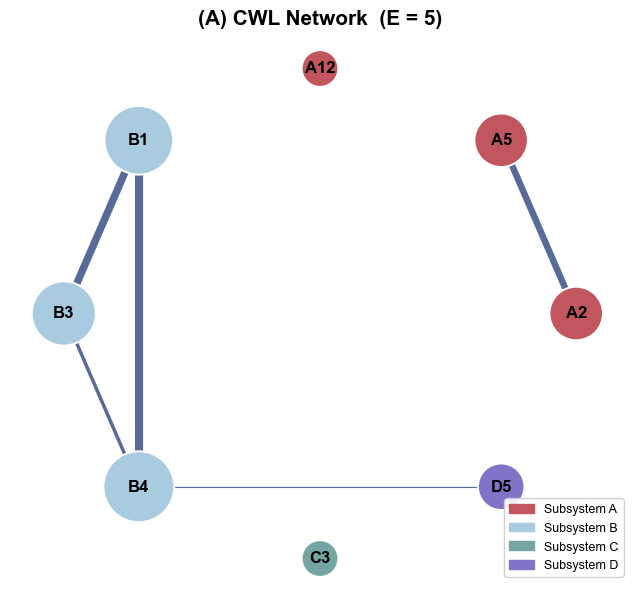

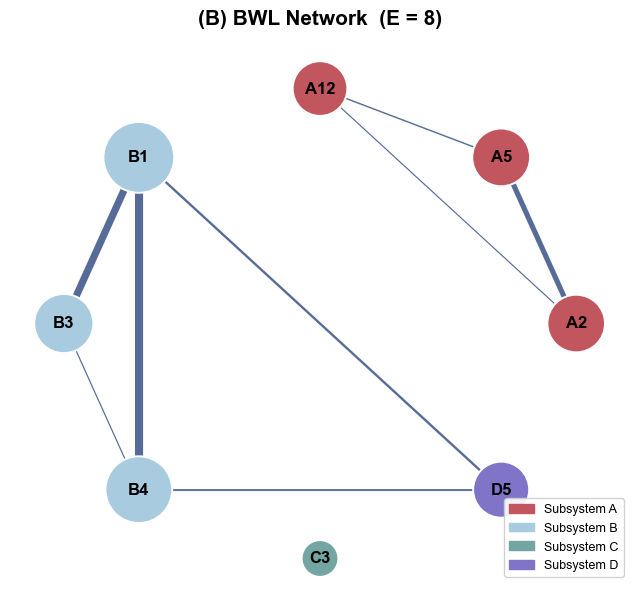

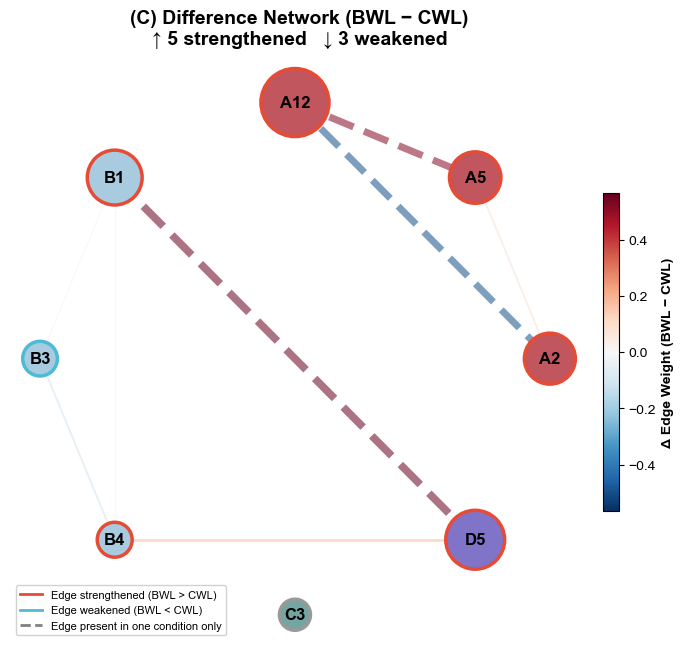

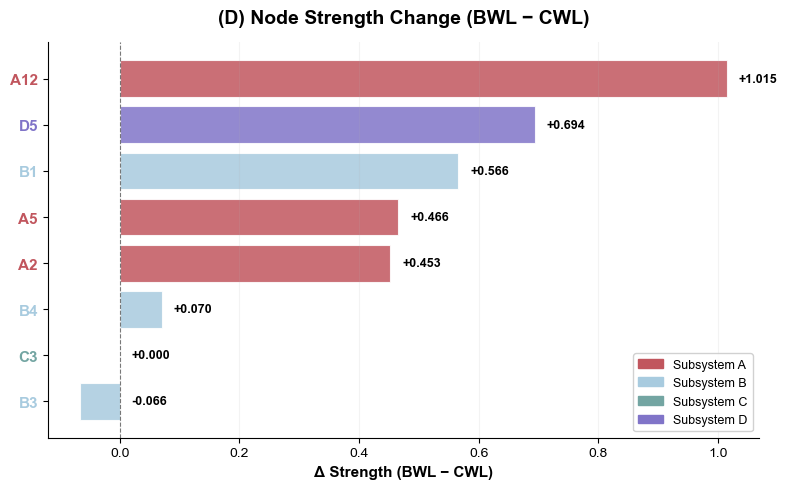

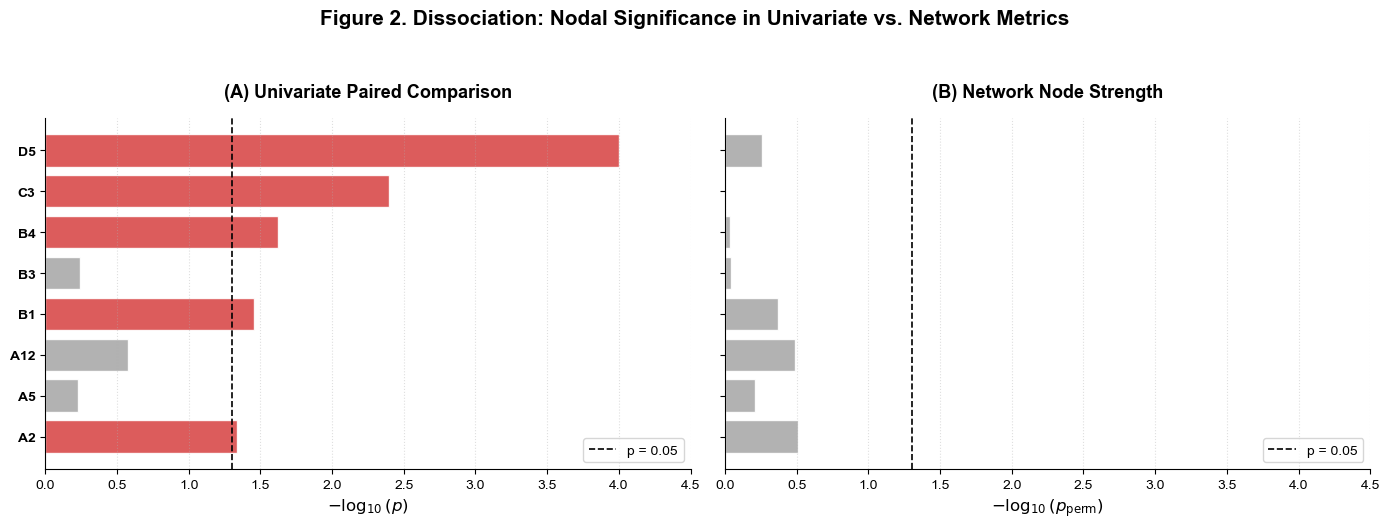

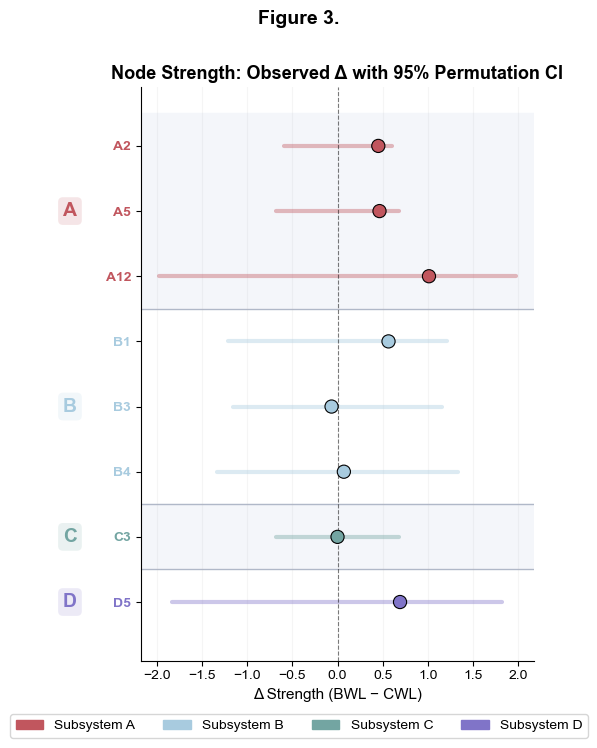

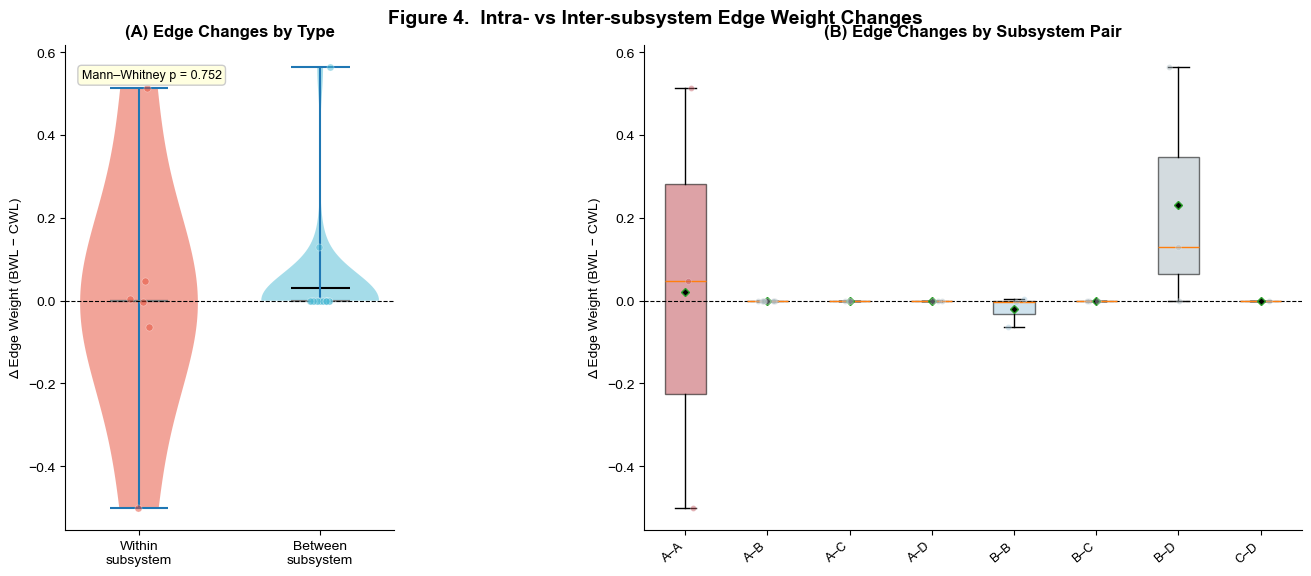

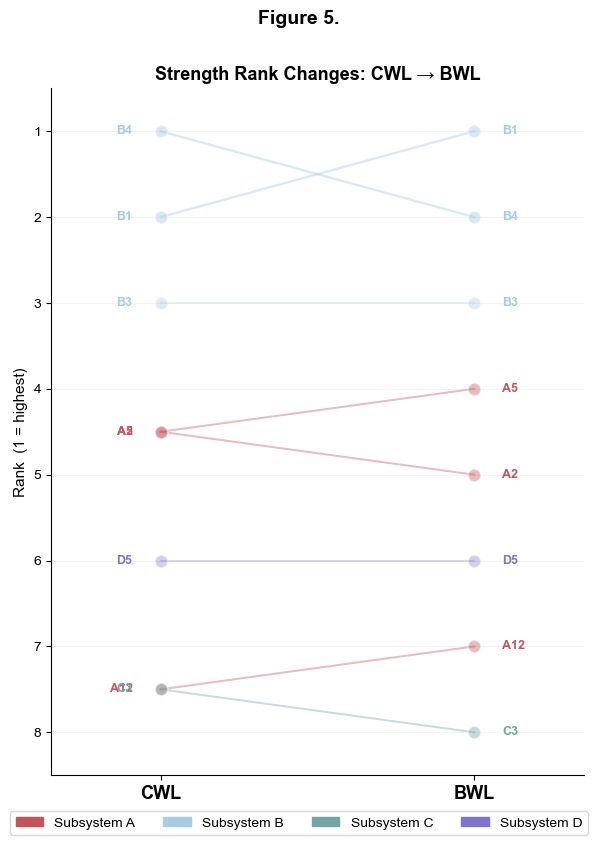


📂 All figures saved to output\figures/


In [5]:
# ============================================================
#  Cell 5 — ALL FIGURES
# ============================================================

%matplotlib inline
plt.close("all")

# ── Shared helpers ─────────────────────────────────────────

def _scale(values, lo=NODE_SIZE_RANGE[0], hi=NODE_SIZE_RANGE[1]):
    a = np.asarray(values, dtype=float)
    if a.max() == a.min():
        return np.full_like(a, (lo + hi) / 2)
    return lo + (a - a.min()) * (hi - lo) / (a.max() - a.min())


SUB_LEG = [mpatches.Patch(color=SUBSYSTEM_COLORS[s], label=f"Subsystem {s}")
           for s in sorted(SUBSYSTEM_COLORS)]

fixed_pos = nx.circular_layout(NODE_COLS)


# ═══════════════════════════════════════════════════════════
#  Fig 1a / 1b — Condition Networks
# ═══════════════════════════════════════════════════════════

def plot_network(G, node_cols, strength, ax, title, pos):
    colors = [SUBSYSTEM_COLORS.get(n[0], "#BDBDBD") for n in node_cols]
    sizes  = _scale(strength.reindex(node_cols).fillna(0).values)
    edges  = list(G.edges(data=True))
    if edges:
        w = np.array([d["weight"] for _, _, d in edges])
        widths = EDGE_WIDTH_RANGE[0] + EDGE_WIDTH_RANGE[1] * (w - w.min()) / (w.max() - w.min() + 1e-12)
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges,
                               width=widths + 0.5,
                               edge_color=EDGE_HALO_COLOR, alpha=0.3)
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges,
                               width=widths,
                               edge_color=EDGE_COLOR, alpha=0.85)
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=node_cols,
                           node_color=colors, node_size=sizes,
                           linewidths=1.4, edgecolors="white")
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=12,
                            font_weight="bold", font_color="black")
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14)
    ax.axis("off")


# Fig 1a — CWL
fig1a, ax = plt.subplots(figsize=(8, 7))
plot_network(obs_cwl["graph"], NODE_COLS, obs_cwl["strength"], ax,
             f"(A) {COND1_LABEL} Network  (E = {obs_cwl['graph'].number_of_edges()})",
             fixed_pos)
ax.legend(handles=SUB_LEG, loc="lower right", fontsize=9, framealpha=0.9)
fig1a.savefig(FIG_DIR / f"Fig1a_{COND1_LABEL}_network.{FIG_FORMAT}",
              dpi=FIG_DPI, bbox_inches="tight", facecolor="white")
plt.show(); plt.close(fig1a)

# Fig 1b — BWL
fig1b, ax = plt.subplots(figsize=(8, 7))
plot_network(obs_bwl["graph"], NODE_COLS, obs_bwl["strength"], ax,
             f"(B) {COND2_LABEL} Network  (E = {obs_bwl['graph'].number_of_edges()})",
             fixed_pos)
ax.legend(handles=SUB_LEG, loc="lower right", fontsize=9, framealpha=0.9)
fig1b.savefig(FIG_DIR / f"Fig1b_{COND2_LABEL}_network.{FIG_FORMAT}",
              dpi=FIG_DPI, bbox_inches="tight", facecolor="white")
plt.show(); plt.close(fig1b)


# ═══════════════════════════════════════════════════════════
#  Fig 1c — Difference Network
# ═══════════════════════════════════════════════════════════

def plot_difference_network(G_cwl, G_bwl, node_cols,
                            strength_cwl, strength_bwl, ax, pos):
    def _adj(G):
        d = {}
        for u, v, data in G.edges(data=True):
            d[tuple(sorted([u, v]))] = data.get("signed_weight",
                                                  data.get("weight", 0.0))
        return d

    adj1, adj2 = _adj(G_cwl), _adj(G_bwl)
    all_keys = set(adj1) | set(adj2)

    edge_data = []
    for key in all_keys:
        w1, w2 = adj1.get(key, 0.0), adj2.get(key, 0.0)
        diff = w2 - w1
        if abs(diff) > 1e-10:
            only_one = (w1 == 0.0 or w2 == 0.0)
            edge_data.append((key[0], key[1], diff, only_one))

    if not edge_data:
        ax.text(0.5, 0.5, "No edge differences",
                ha="center", va="center", fontsize=12,
                transform=ax.transAxes)
        ax.axis("off"); return

    diffs   = [d for _, _, d, _ in edge_data]
    abs_max = max(abs(d) for d in diffs)
    norm    = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
    cmap    = plt.get_cmap("RdBu_r")

    for u, v, d, only_one in edge_data:
        color = cmap(norm(d))
        width = 0.8 + (abs(d) / (abs_max + 1e-12)) * 4.7
        style = "dashed" if only_one else "solid"
        alpha = 0.55 if only_one else 0.85
        G_tmp = nx.Graph(); G_tmp.add_edge(u, v)
        nx.draw_networkx_edges(G_tmp, pos, ax=ax, edgelist=[(u, v)],
                               width=width, edge_color=[color],
                               style=style, alpha=alpha)

    delta_s = (strength_bwl.reindex(node_cols).fillna(0) -
               strength_cwl.reindex(node_cols).fillna(0))
    node_sizes    = _scale(delta_s.abs().values, 500, 2400)
    face_colors   = [SUBSYSTEM_COLORS.get(n[0], "#BDBDBD") for n in node_cols]
    border_colors = ["#E64B35" if delta_s[n] > 0 else
                     "#4DBBD5" if delta_s[n] < 0 else
                     "#999999" for n in node_cols]

    G_h = nx.Graph(); G_h.add_nodes_from(node_cols)
    nx.draw_networkx_nodes(G_h, pos, ax=ax, nodelist=node_cols,
                           node_color=face_colors, node_size=node_sizes,
                           linewidths=2.5, edgecolors=border_colors)
    nx.draw_networkx_labels(G_h, pos, ax=ax, font_size=12,
                            font_weight="bold", font_color="black")

    sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.55, aspect=20, pad=0.02)
    cbar.set_label(f"Δ Edge Weight ({COND2_LABEL} − {COND1_LABEL})",
                   fontsize=10, fontweight="bold")

    n_up = sum(1 for _, _, d, _ in edge_data if d > 0)
    n_dn = sum(1 for _, _, d, _ in edge_data if d < 0)

    legend_elems = [
        Line2D([0], [0], color="#E64B35", lw=2,
               label=f"Edge strengthened ({COND2_LABEL} > {COND1_LABEL})"),
        Line2D([0], [0], color="#4DBBD5", lw=2,
               label=f"Edge weakened ({COND2_LABEL} < {COND1_LABEL})"),
        Line2D([0], [0], color="grey", lw=2, ls="dashed",
               label="Edge present in one condition only"),
    ]
    ax.legend(handles=legend_elems, loc="lower left", fontsize=8, framealpha=0.9)
    ax.set_title(f"(C) Difference Network ({COND2_LABEL} − {COND1_LABEL})\n"
                 f"↑ {n_up} strengthened   ↓ {n_dn} weakened",
                 fontsize=14, fontweight="bold", pad=14)
    ax.axis("off")


fig1c, ax = plt.subplots(figsize=(9, 7.5))
plot_difference_network(obs_cwl["graph"], obs_bwl["graph"], NODE_COLS,
                        obs_cwl["strength"], obs_bwl["strength"],
                        ax, fixed_pos)
fig1c.savefig(FIG_DIR / f"Fig1c_difference_network.{FIG_FORMAT}",
              dpi=FIG_DPI, bbox_inches="tight", facecolor="white")
plt.show(); plt.close(fig1c)


# ═══════════════════════════════════════════════════════════
#  Fig 1d — Strength Change Bar Chart
# ═══════════════════════════════════════════════════════════

def plot_strength_change_bar(strength_cwl, strength_bwl, node_cols, ax):
    delta_s = (strength_bwl.reindex(node_cols).fillna(0) -
               strength_cwl.reindex(node_cols).fillna(0))
    order = delta_s.sort_values(ascending=True).index
    delta_sorted = delta_s[order]
    colors = [SUBSYSTEM_COLORS.get(n[0], "#BDBDBD") for n in order]

    bars = ax.barh(range(len(order)), delta_sorted.values, color=colors,
                   edgecolor="white", linewidth=0.8, alpha=0.85)
    ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.5)
    ax.set_yticks(range(len(order)))
    ylabels = ax.set_yticklabels(order, fontsize=11, fontweight="bold")
    for lbl in ylabels:
        lbl.set_color(SUBSYSTEM_COLORS.get(lbl.get_text()[0], "#333"))

    for i, (val, bar) in enumerate(zip(delta_sorted.values, bars)):
        x_pos = max(val, 0) + 0.02
        ax.text(x_pos, i, f"{val:+.3f}", ha="left", va="center",
                fontsize=9, fontweight="bold")

    ax.set_xlabel(f"Δ Strength ({COND2_LABEL} − {COND1_LABEL})",
                  fontsize=11, fontweight="bold")
    ax.set_title(f"(D) Node Strength Change ({COND2_LABEL} − {COND1_LABEL})",
                 fontsize=14, fontweight="bold", pad=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.15)


fig1d, ax = plt.subplots(figsize=(8, 5))
plot_strength_change_bar(obs_cwl["strength"], obs_bwl["strength"], NODE_COLS, ax)
ax.legend(handles=SUB_LEG, loc="lower right", fontsize=9, framealpha=0.9)
plt.tight_layout()
fig1d.savefig(FIG_DIR / f"Fig1d_strength_change_bar.{FIG_FORMAT}",
              dpi=FIG_DPI, bbox_inches="tight", facecolor="white")
plt.show(); plt.close(fig1d)


# ═══════════════════════════════════════════════════════════
#  Fig 2 — Dissociation: Univariate vs Network
# ═══════════════════════════════════════════════════════════

network_p = dict(zip(res["node_dfs"]["strength"]["node"],
                     res["node_dfs"]["strength"]["p_perm"]))

P_LIMIT = 1e-4
X_MAX   = 4.5

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

def draw_p_bar(ax, p_dict, title, xlabel):
    vals = [-np.log10(max(p_dict.get(n, 1), P_LIMIT)) for n in NODE_COLS]
    cols = ["#D94A4A" if p_dict.get(n, 1) < ALPHA else "#AAAAAA" for n in NODE_COLS]
    ax.barh(range(len(NODE_COLS)), vals, color=cols, edgecolor="white", alpha=0.9)
    ax.axvline(-np.log10(ALPHA), color="black", ls="--", lw=1.2,
               label=f"p = {ALPHA}", zorder=3)
    ax.set_xlim(0, X_MAX)
    ax.set_xlabel(xlabel, fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=15)
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.legend(loc="lower right", frameon=True, fancybox=True)

draw_p_bar(ax1, UNIVARIATE_P, "(A) Univariate Paired Comparison",
           r"$-\log_{10}(p)$")
draw_p_bar(ax2, network_p, "(B) Network Node Strength",
           r"$-\log_{10}(p_{\mathrm{perm}})$")

ax1.set_yticks(range(len(NODE_COLS)))
ax1.set_yticklabels(NODE_COLS, fontsize=10, fontweight="bold")
for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig2.suptitle("Figure 2. Dissociation: Nodal Significance in Univariate vs. Network Metrics",
              fontsize=15, fontweight="bold", y=1.05)
plt.tight_layout()
fig2.savefig(FIG_DIR / f"Fig2_dissociation.{FIG_FORMAT}",
             dpi=FIG_DPI, bbox_inches="tight")
plt.show(); plt.close(fig2)


# ═══════════════════════════════════════════════════════════
#  Fig 3 — Forest Plot (Strength)
# ═══════════════════════════════════════════════════════════

sub_ids    = [n[0] for n in NODE_COLS]
boundaries = [i for i in range(1, len(sub_ids)) if sub_ids[i] != sub_ids[i - 1]]

fig3, ax = plt.subplots(figsize=(5, 7))

ndf  = res["node_dfs"]["strength"]
perm = res["perm_nm"]["strength"]
obs_diff = ndf["diff"].values
ci_lo    = np.percentile(perm, 2.5,  axis=0)
ci_hi    = np.percentile(perm, 97.5, axis=0)
y        = np.arange(len(NODE_COLS))
colors   = [SUBSYSTEM_COLORS.get(n[0], "#999") for n in NODE_COLS]

seg_starts = [0] + boundaries
seg_ends   = boundaries + [len(NODE_COLS)]
for k, (s, e) in enumerate(zip(seg_starts, seg_ends)):
    fc = "#F4F6FA" if k % 2 == 0 else "white"
    ax.axhspan(s - 0.5, e - 0.5, color=fc, zorder=0)
for b in boundaries:
    ax.axhline(b - 0.5, color="#B0B8C8", lw=1, ls="-", zorder=1)

for i in range(len(NODE_COLS)):
    ax.plot([ci_lo[i], ci_hi[i]], [i, i],
            color=colors[i], lw=3, alpha=0.4, solid_capstyle="round")
ax.scatter(obs_diff, y, c=colors, s=90, zorder=5,
           edgecolors="black", linewidths=0.8)
ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_yticks(y)
ylabels = ax.set_yticklabels(NODE_COLS, fontsize=10, fontweight="bold")
for lbl in ylabels:
    lbl.set_color(SUBSYSTEM_COLORS.get(lbl.get_text()[0], "#333"))

for k, (s, e) in enumerate(zip(seg_starts, seg_ends)):
    mid = (s + e - 1) / 2.0
    letter = NODE_COLS[s][0]
    ax.text(-0.18, mid, letter, fontsize=14, fontweight="bold",
            color=SUBSYSTEM_COLORS.get(letter, "#333"),
            ha="center", va="center",
            transform=ax.get_yaxis_transform(),
            bbox=dict(boxstyle="round,pad=0.25",
                      fc=SUBSYSTEM_COLORS.get(letter, "#EEE"),
                      alpha=0.15, ec="none"))

ax.invert_yaxis()
ax.set_xlabel(f"Δ Strength ({COND2_LABEL} − {COND1_LABEL})", fontsize=11)
ax.set_title("Node Strength: Observed Δ with 95% Permutation CI",
             fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig3.legend(handles=SUB_LEG, loc="lower center", ncol=4,
            fontsize=10, bbox_to_anchor=(0.5, -0.04))
fig3.suptitle("Figure 3.", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig3.savefig(FIG_DIR / f"Fig3_forest_plot.{FIG_FORMAT}",
             dpi=FIG_DPI, bbox_inches="tight")
plt.show(); plt.close(fig3)


# ═══════════════════════════════════════════════════════════
#  Fig 4 — Intra- vs Inter-subsystem Edge Changes
# ═══════════════════════════════════════════════════════════

edf = res["edge_df"].copy()
edf["type"] = edf.apply(
    lambda r: "Within" if r["node_i"][0] == r["node_j"][0] else "Between",
    axis=1)
edf["pair"] = edf.apply(
    lambda r: (f"{r['node_i'][0]}–{r['node_i'][0]}"
               if r["node_i"][0] == r["node_j"][0]
               else f"{min(r['node_i'][0], r['node_j'][0])}–"
                    f"{max(r['node_i'][0], r['node_j'][0])}"),
    axis=1)

fig4 = plt.figure(figsize=(13, 5.5), constrained_layout=True)
gs4  = gridspec.GridSpec(1, 2, width_ratios=[1, 2], wspace=0.30, figure=fig4)
ax1  = fig4.add_subplot(gs4[0])
ax2  = fig4.add_subplot(gs4[1])

# Left: violin
within_d  = edf.loc[edf["type"] == "Within",  "diff"].values
between_d = edf.loc[edf["type"] == "Between", "diff"].values

parts = ax1.violinplot([within_d, between_d], positions=[1, 2],
                       showmeans=True, showmedians=True, widths=0.65)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(["#E64B35", "#4DBBD5"][i]); pc.set_alpha(0.5)
parts["cmeans"].set_color("black")
parts["cmedians"].set_color("grey")

rng_j = np.random.default_rng(42)
for i, (data, pos) in enumerate(zip([within_d, between_d], [1, 2])):
    jit = rng_j.uniform(-0.06, 0.06, len(data))
    ax1.scatter(np.full(len(data), pos) + jit, data,
                c=["#E64B35", "#4DBBD5"][i], s=26, alpha=0.5,
                edgecolors="white", linewidths=0.4, zorder=3)

ax1.axhline(0, color="black", lw=0.8, ls="--")
ax1.set_xticks([1, 2])
ax1.set_xticklabels(["Within\nsubsystem", "Between\nsubsystem"], fontsize=10)
ax1.set_ylabel(f"Δ Edge Weight ({COND2_LABEL} − {COND1_LABEL})", fontsize=10)
ax1.set_title("(A) Edge Changes by Type", fontsize=12, fontweight="bold")
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)

mw_p = None
if len(within_d) > 0 and len(between_d) > 0:
    try:
        _, mw_p = mannwhitneyu(within_d, between_d, alternative="two-sided")
        ax1.text(0.05, 0.95, f"Mann–Whitney p = {mw_p:.3f}",
                 transform=ax1.transAxes, fontsize=9, va="top",
                 bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="#ccc"))
    except Exception:
        pass

# Right: boxplot by subsystem pair
pair_order = sorted(edf["pair"].unique())
pair_data  = [edf.loc[edf["pair"] == p, "diff"].values for p in pair_order]
pair_cols  = []
for p in pair_order:
    a, b = p.split("–")
    pair_cols.append(SUBSYSTEM_COLORS.get(a, "#AAA") if a == b else "#B0BEC5")

bp = ax2.boxplot(pair_data, positions=range(len(pair_order)),
                 widths=0.5, patch_artist=True, showmeans=True,
                 meanprops=dict(marker="D", markerfacecolor="black", ms=4))
for patch, c in zip(bp["boxes"], pair_cols):
    patch.set_facecolor(c); patch.set_alpha(0.55)

rng_j2 = np.random.default_rng(7)
for i, (d, c) in enumerate(zip(pair_data, pair_cols)):
    jit = rng_j2.uniform(-0.12, 0.12, len(d))
    ax2.scatter(np.full(len(d), i) + jit, d, c=c, s=18,
                alpha=0.45, edgecolors="white", linewidths=0.3, zorder=3)

ax2.axhline(0, color="black", lw=0.8, ls="--")
ax2.set_xticks(range(len(pair_order)))
ax2.set_xticklabels(pair_order, fontsize=9, rotation=40, ha="right")
ax2.set_ylabel(f"Δ Edge Weight ({COND2_LABEL} − {COND1_LABEL})", fontsize=10)
ax2.set_title("(B) Edge Changes by Subsystem Pair",
              fontsize=12, fontweight="bold")
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

fig4.suptitle("Figure 4.  Intra- vs Inter-subsystem Edge Weight Changes",
              fontsize=14, fontweight="bold", y=1.02)
fig4.savefig(FIG_DIR / f"Fig4_subsystem_edges.{FIG_FORMAT}",
             dpi=FIG_DPI, bbox_inches="tight")
plt.show(); plt.close(fig4)


# ═══════════════════════════════════════════════════════════
#  Fig 5 — Bump Chart (Strength Rank)
# ═══════════════════════════════════════════════════════════

fig5, ax = plt.subplots(figsize=(6, 8))

rank_c1 = ndf[COND1].rank(ascending=False).values.astype(float)
rank_c2 = ndf[COND2].rank(ascending=False).values.astype(float)

for i, node in enumerate(NODE_COLS):
    col  = SUBSYSTEM_COLORS.get(node[0], "#999")
    jump = abs(rank_c1[i] - rank_c2[i])
    lw   = 1.2 + jump * 0.45
    alph = 0.35 + min(jump / 12, 0.55)
    ax.plot([0, 1], [rank_c1[i], rank_c2[i]], "o-",
            color=col, lw=lw, alpha=alph, ms=9,
            markeredgecolor="white", markeredgewidth=1.2)
    ax.text(-0.09, rank_c1[i], node, fontsize=9,
            fontweight="bold", ha="right", va="center", color=col)
    ax.text(1.09,  rank_c2[i], node, fontsize=9,
            fontweight="bold", ha="left",  va="center", color=col)

ax.set_xlim(-0.35, 1.35)
ax.set_ylim(len(NODE_COLS) + 0.5, 0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels([COND1_LABEL, COND2_LABEL], fontsize=13, fontweight="bold")
ax.set_ylabel("Rank  (1 = highest)", fontsize=11)
ax.set_title(f"Strength Rank Changes: {COND1_LABEL} → {COND2_LABEL}",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig5.legend(handles=SUB_LEG, loc="lower center", ncol=4,
            fontsize=10, bbox_to_anchor=(0.5, -0.03))
fig5.suptitle("Figure 5.", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig5.savefig(FIG_DIR / f"Fig5_bump_chart.{FIG_FORMAT}",
             dpi=FIG_DPI, bbox_inches="tight")
plt.show(); plt.close(fig5)

print(f"\n📂 All figures saved to {FIG_DIR}/")

## Summary Tables & Data Export

In [6]:
# ============================================================
#  Cell 6 — SUMMARY TABLES & EXPORT
# ============================================================

print("📊 --- FIGURE DATA SUMMARY TABLES ---\n")

# Table 1: Node Strength + Univariate p
df_nodes = res["node_dfs"]["strength"][["node", COND1, COND2, "diff", "p_perm"]].copy()
df_nodes.columns = ["Node", "Str_CWL", "Str_BWL", "Str_Diff", "Str_p_perm"]
df_nodes["Univariate_p"] = df_nodes["Node"].map(UNIVARIATE_P).fillna(1.0)

print("Table 1: Node Strength & Significance (Fig 1d, 2, 3)")
display(df_nodes.sort_values("Node").style.background_gradient(
    subset=["Str_Diff"], cmap="RdBu_r"))

# Table 2: Within vs Between edge stats
within_stats  = pd.Series(within_d).describe()
between_stats = pd.Series(between_d).describe()

df_fig4a = pd.DataFrame({
    "Within_Subsystem":  within_stats,
    "Between_Subsystem": between_stats,
}).T
if mw_p is not None:
    df_fig4a["Mann-Whitney_p"] = mw_p

print("\nTable 2: Edge Weight Change Distribution (Fig 4A)")
display(df_fig4a)

# Table 3: Subsystem pairwise edge shifts
df_fig4b = (edf.groupby("pair")["diff"]
            .agg(["mean", "std", "count"]).reset_index())
df_fig4b.columns = ["Subsystem_Pair", "Mean_Delta_Weight", "Std", "N_Edges"]

print("\nTable 3: Subsystem Pairwise Edge Shifts (Fig 4B)")
display(df_fig4b.sort_values("Mean_Delta_Weight", ascending=False))

# Table 4: Strength rank dynamics
df_ranks = pd.DataFrame({"Node": NODE_COLS})
df_ranks["Rank_CWL"] = res["node_dfs"]["strength"][COND1].rank(ascending=False).values
df_ranks["Rank_BWL"] = res["node_dfs"]["strength"][COND2].rank(ascending=False).values
df_ranks["Rank_Jump"] = (df_ranks["Rank_CWL"] - df_ranks["Rank_BWL"]).astype(int)

print("\nTable 4: Strength Rank Dynamics (Fig 5)")
display(df_ranks.sort_values("Rank_BWL"))

# ── Export all summary tables ────────────────────────────
df_nodes.to_excel(TAB_DIR / "summary_node_strength.xlsx", index=False)
df_fig4a.to_excel(TAB_DIR / "summary_edge_within_between.xlsx")
df_fig4b.to_excel(TAB_DIR / "summary_subsystem_pairs.xlsx", index=False)
df_ranks.to_excel(TAB_DIR / "summary_rank_dynamics.xlsx", index=False)

print(f"\n📂 All tables saved to {TAB_DIR}/")
print(f"📂 All figures saved to {FIG_DIR}/")
print("\n✅ Analysis complete.")

📊 --- FIGURE DATA SUMMARY TABLES ---

Table 1: Node Strength & Significance (Fig 1d, 2, 3)


,Node,Str_CWL,Str_BWL,Str_Diff,Str_p_perm,Univariate_p
2,A12,0.000000,1.014568,1.014568,0.323668,0.263000
0,A2,0.763567,1.216125,0.452558,0.310369,0.046000
1,A5,0.763567,1.229383,0.465816,0.619638,0.588000
3,B1,1.700000,2.265775,0.565775,0.424158,0.035000
4,B3,1.393913,1.327826,-0.066087,0.901710,0.570000
5,B4,1.848875,1.919248,0.070373,0.928707,0.024000
6,C3,0.000000,0.000000,0.000000,1.000000,0.004000
7,D5,0.412353,1.105893,0.693539,0.555744,0.000100



Table 2: Edge Weight Change Distribution (Fig 4A)


,count,mean,std,min,25%,50%,75%,max,Mann-Whitney_p
Within_Subsystem,6.0,-0.000064,0.322808,-0.500655,-0.047826,0.000435,0.03716,0.513913,0.75206
Between_Subsystem,22.0,0.031525,0.122241,0.000000,0.000000,0.000000,0.00000,0.564905,0.75206



Table 3: Subsystem Pairwise Edge Shifts (Fig 4B)


,Subsystem_Pair,Mean_Delta_Weight,Std,N_Edges
6,B–D,0.231180,0.296085,3
0,A–A,0.020452,0.507849,3
2,A–C,0.000000,0.000000,3
1,A–B,0.000000,0.000000,9
3,A–D,0.000000,0.000000,3
5,B–C,0.000000,0.000000,3
7,C–D,0.000000,NaN,1
4,B–B,-0.020580,0.036608,3



Table 4: Strength Rank Dynamics (Fig 5)


,Node,Rank_CWL,Rank_BWL,Rank_Jump
3,B1,2.0,1.0,1
5,B4,1.0,2.0,-1
4,B3,3.0,3.0,0
1,A5,4.5,4.0,0
0,A2,4.5,5.0,0
7,D5,6.0,6.0,0
2,A12,7.5,7.0,0
6,C3,7.5,8.0,0



📂 All tables saved to output\tables/
📂 All figures saved to output\figures/

✅ Analysis complete.
